# Análise Exploratória de Dados de Energia

Este notebook realiza uma análise exploratória completa dos dados de consumo de energia sintéticos, incluindo visualizações para facilitar a compreensão dos padrões e tendências.


In [12]:
# Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuração de estilo para os gráficos
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
        
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


## 1. Carregamento dos Dados


In [13]:
# Carregar o dataset
df = pd.read_csv('energy_readings_sinteticos.csv')

# Converter a coluna de timestamp para datetime
df['ts'] = pd.to_datetime(df['ts'])

print(f"Dataset carregado com sucesso!")
print(f"Shape: {df.shape}")
print(f"\nPrimeiras linhas:")
df.head()


Dataset carregado com sucesso!
Shape: (276480, 13)

Primeiras linhas:


,ts,org_id,site_id,andar,device_id,device_type,kw,kwh_interval,emissoes_tco2e,temp_ext,eh_fds,eh_horario_comercial,is_anomaly
0,2025-01-01 00:00:00,org_greenhub,site_centro,1,site_centro_F1_HVAC_1,HVAC,8.412576,2.103144,0.000168,26.745071,0,0,0
1,2025-01-01 00:15:00,org_greenhub,site_centro,1,site_centro_F1_HVAC_1,HVAC,8.577123,2.144281,0.000172,26.054216,0,0,0
2,2025-01-01 00:30:00,org_greenhub,site_centro,1,site_centro_F1_HVAC_1,HVAC,6.664687,1.666172,0.000133,27.493638,0,0,0
3,2025-01-01 00:45:00,org_greenhub,site_centro,1,site_centro_F1_HVAC_1,HVAC,7.944312,1.986078,0.000159,29.064906,0,0,0
4,2025-01-01 01:00:00,org_greenhub,site_centro,1,site_centro_F1_HVAC_1,HVAC,8.523837,2.130959,0.000170,26.684046,0,0,0


## 2. Informações Básicas do Dataset


In [14]:
# Informações gerais
print("=" * 60)
print("INFORMAÇÕES GERAIS DO DATASET")
print("=" * 60)
print(f"\nNúmero de linhas: {len(df):,}")
print(f"Número de colunas: {len(df.columns)}")
print(f"\nPeríodo dos dados:")
print(f"  Início: {df['ts'].min()}")
print(f"  Fim: {df['ts'].max()}")
print(f"  Duração: {(df['ts'].max() - df['ts'].min()).days} dias")

print(f"\nColunas do dataset:")
print(df.columns.tolist())

print(f"\nTipos de dados:")
print(df.dtypes)

print(f"\nValores nulos:")
print(df.isnull().sum())

print(f"\nEstatísticas descritivas:")
df.describe()


INFORMAÇÕES GERAIS DO DATASET

Número de linhas: 276,480
Número de colunas: 13

Período dos dados:
  Início: 2025-01-01 00:00:00
  Fim: 2025-01-15 23:45:00
  Duração: 14 dias

Colunas do dataset:
['ts', 'org_id', 'site_id', 'andar', 'device_id', 'device_type', 'kw', 'kwh_interval', 'emissoes_tco2e', 'temp_ext', 'eh_fds', 'eh_horario_comercial', 'is_anomaly']

Tipos de dados:
ts                      datetime64[ns]
org_id                          object
site_id                         object
andar                            int64
device_id                       object
device_type                     object
kw                             float64
kwh_interval                   float64
emissoes_tco2e                 float64
temp_ext                       float64
eh_fds                           int64
eh_horario_comercial             int64
is_anomaly                       int64
dtype: object

Valores nulos:
ts                      0
org_id                  0
site_id                 0
andar  

,ts,andar,kw,kwh_interval,emissoes_tco2e,temp_ext,eh_fds,eh_horario_comercial,is_anomaly
count,276480,276480.000000,276480.000000,276480.000000,2.764800e+05,276480.000000,276480.000000,276480.000000,276480.000000
mean,2025-01-08 11:52:29.999999744,2.625000,1.780979,0.445245,3.561957e-05,26.059766,0.266667,0.416667,0.004999
min,2025-01-01 00:00:00,1.000000,0.000000,0.000000,0.000000e+00,17.172320,0.000000,0.000000,0.000000
25%,2025-01-04 17:56:15,1.750000,0.003448,0.000862,6.895441e-08,23.337840,0.000000,0.000000,0.000000
50%,2025-01-08 11:52:30,2.500000,0.625711,0.156428,1.251421e-05,26.096376,0.000000,0.000000,0.000000
75%,2025-01-12 05:48:45,3.250000,1.625403,0.406351,3.250807e-05,28.673615,1.000000,1.000000,0.000000
max,2025-01-15 23:45:00,5.000000,104.818058,26.204514,2.096361e-03,35.366588,1.000000,1.000000,1.000000
std,NaN,1.316959,4.115327,1.028832,8.230654e-05,3.193746,0.442217,0.493008,0.070524


## 3. Análise de Categorias


In [15]:
# Análise de categorias
print("=" * 60)
print("ANÁLISE DE CATEGORIAS")
print("=" * 60)

print(f"\nOrganizações: {df['org_id'].unique()}")
print(f"\nSites: {df['site_id'].unique()}")
print(f"\nAndares: {sorted(df['andar'].unique())}")
print(f"\nTipos de dispositivos: {df['device_type'].unique()}")
print(f"\nNúmero de dispositivos únicos: {df['device_id'].nunique()}")

print(f"\nDistribuição por tipo de dispositivo:")
print(df['device_type'].value_counts())

print(f"\nDistribuição por site:")
print(df['site_id'].value_counts())

print(f"\nDistribuição por andar:")
print(df['andar'].value_counts().sort_index())

print(f"\nAnomalias detectadas: {df['is_anomaly'].sum():,} ({df['is_anomaly'].mean()*100:.2f}%)")
print(f"Finais de semana: {df['eh_fds'].sum():,} ({df['eh_fds'].mean()*100:.2f}%)")
print(f"Horário comercial: {df['eh_horario_comercial'].sum():,} ({df['eh_horario_comercial'].mean()*100:.2f}%)")


ANÁLISE DE CATEGORIAS

Organizações: ['org_greenhub']

Sites: ['site_centro' 'site_zonasul']

Andares: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Tipos de dispositivos: ['HVAC' 'ILUMINACAO' 'TI' 'TOMADAS']

Número de dispositivos únicos: 192

Distribuição por tipo de dispositivo:
device_type
ILUMINACAO    115200
TOMADAS        92160
TI             46080
HVAC           23040
Name: count, dtype: int64

Distribuição por site:
site_id
site_centro     172800
site_zonasul    103680
Name: count, dtype: int64

Distribuição por andar:
andar
1    69120
2    69120
3    69120
4    34560
5    34560
Name: count, dtype: int64

Anomalias detectadas: 1,382 (0.50%)
Finais de semana: 73,728 (26.67%)
Horário comercial: 115,200 (41.67%)


## 4. Visualizações - Distribuições e Estatísticas


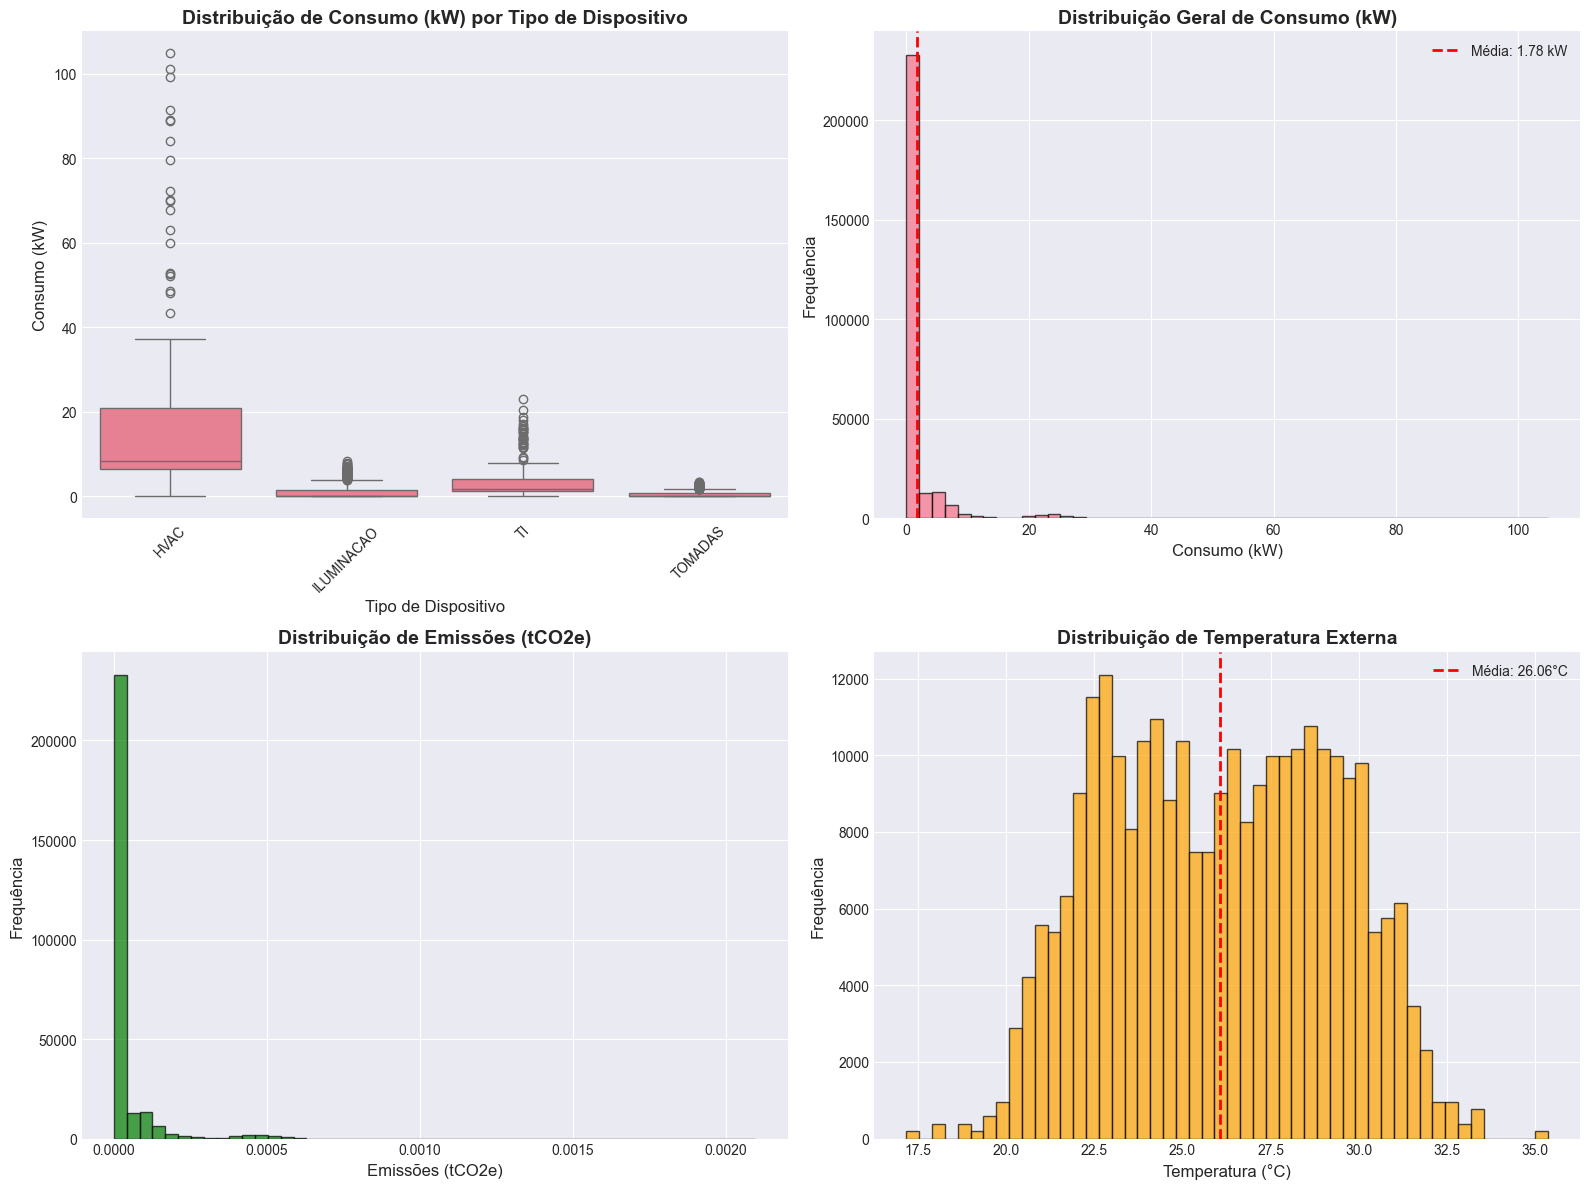

In [16]:
# Gráfico 1: Distribuição de consumo (kW) por tipo de dispositivo
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1.1 - Boxplot de consumo por tipo de dispositivo
ax1 = axes[0, 0]
sns.boxplot(data=df, x='device_type', y='kw', ax=ax1)
ax1.set_title('Distribuição de Consumo (kW) por Tipo de Dispositivo', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tipo de Dispositivo', fontsize=12)
ax1.set_ylabel('Consumo (kW)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# 1.2 - Histograma de consumo geral
ax2 = axes[0, 1]
ax2.hist(df['kw'], bins=50, edgecolor='black', alpha=0.7)
ax2.set_title('Distribuição Geral de Consumo (kW)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Consumo (kW)', fontsize=12)
ax2.set_ylabel('Frequência', fontsize=12)
ax2.axvline(df['kw'].mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {df["kw"].mean():.2f} kW')
ax2.legend()

# 1.3 - Distribuição de emissões
ax3 = axes[1, 0]
ax3.hist(df['emissoes_tco2e'], bins=50, edgecolor='black', alpha=0.7, color='green')
ax3.set_title('Distribuição de Emissões (tCO2e)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Emissões (tCO2e)', fontsize=12)
ax3.set_ylabel('Frequência', fontsize=12)

# 1.4 - Distribuição de temperatura externa
ax4 = axes[1, 1]
ax4.hist(df['temp_ext'], bins=50, edgecolor='black', alpha=0.7, color='orange')
ax4.set_title('Distribuição de Temperatura Externa', fontsize=14, fontweight='bold')
ax4.set_xlabel('Temperatura (°C)', fontsize=12)
ax4.set_ylabel('Frequência', fontsize=12)
ax4.axvline(df['temp_ext'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Média: {df["temp_ext"].mean():.2f}°C')
ax4.legend()

plt.tight_layout()
plt.show()


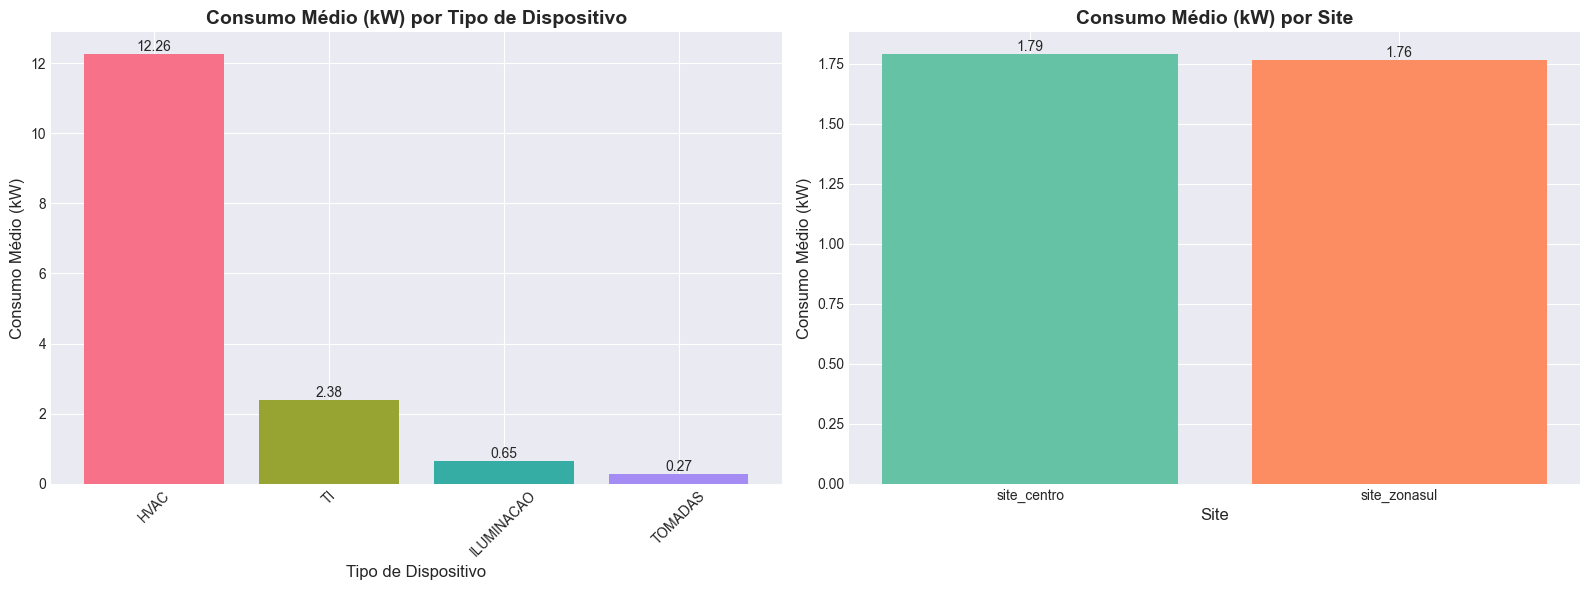

In [17]:
# Gráfico 2: Consumo médio por tipo de dispositivo e site
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2.1 - Consumo médio por tipo de dispositivo
ax1 = axes[0]
consumo_por_tipo = df.groupby('device_type')['kw'].mean().sort_values(ascending=False)
bars = ax1.bar(consumo_por_tipo.index, consumo_por_tipo.values, color=sns.color_palette("husl", len(consumo_por_tipo)))
ax1.set_title('Consumo Médio (kW) por Tipo de Dispositivo', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tipo de Dispositivo', fontsize=12)
ax1.set_ylabel('Consumo Médio (kW)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=10)

# 2.2 - Consumo médio por site
ax2 = axes[1]
consumo_por_site = df.groupby('site_id')['kw'].mean().sort_values(ascending=False)
bars = ax2.bar(consumo_por_site.index, consumo_por_site.values, color=sns.color_palette("Set2", len(consumo_por_site)))
ax2.set_title('Consumo Médio (kW) por Site', fontsize=14, fontweight='bold')
ax2.set_xlabel('Site', fontsize=12)
ax2.set_ylabel('Consumo Médio (kW)', fontsize=12)

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 5. Análise Temporal


In [18]:
# Preparar dados temporais
df['data'] = df['ts'].dt.date
df['hora'] = df['ts'].dt.hour
df['dia_semana'] = df['ts'].dt.day_name()
df['mes'] = df['ts'].dt.month
df['dia'] = df['ts'].dt.day

# Agregar consumo por data
consumo_diario = df.groupby('data').agg({
    'kw': 'sum',
    'kwh_interval': 'sum',
    'emissoes_tco2e': 'sum',
    'temp_ext': 'mean'
}).reset_index()

print("Dados temporais preparados!")
consumo_diario.head()


Dados temporais preparados!


,data,kw,kwh_interval,emissoes_tco2e,temp_ext
0,2025-01-01,37639.019438,9409.754860,0.752780,25.832619
1,2025-01-02,37823.476996,9455.869249,0.756470,26.075722
2,2025-01-03,37895.618076,9473.904519,0.757912,26.041729
3,2025-01-04,18910.166469,4727.541617,0.378203,26.135206
4,2025-01-05,18983.027824,4745.756956,0.379661,26.039399


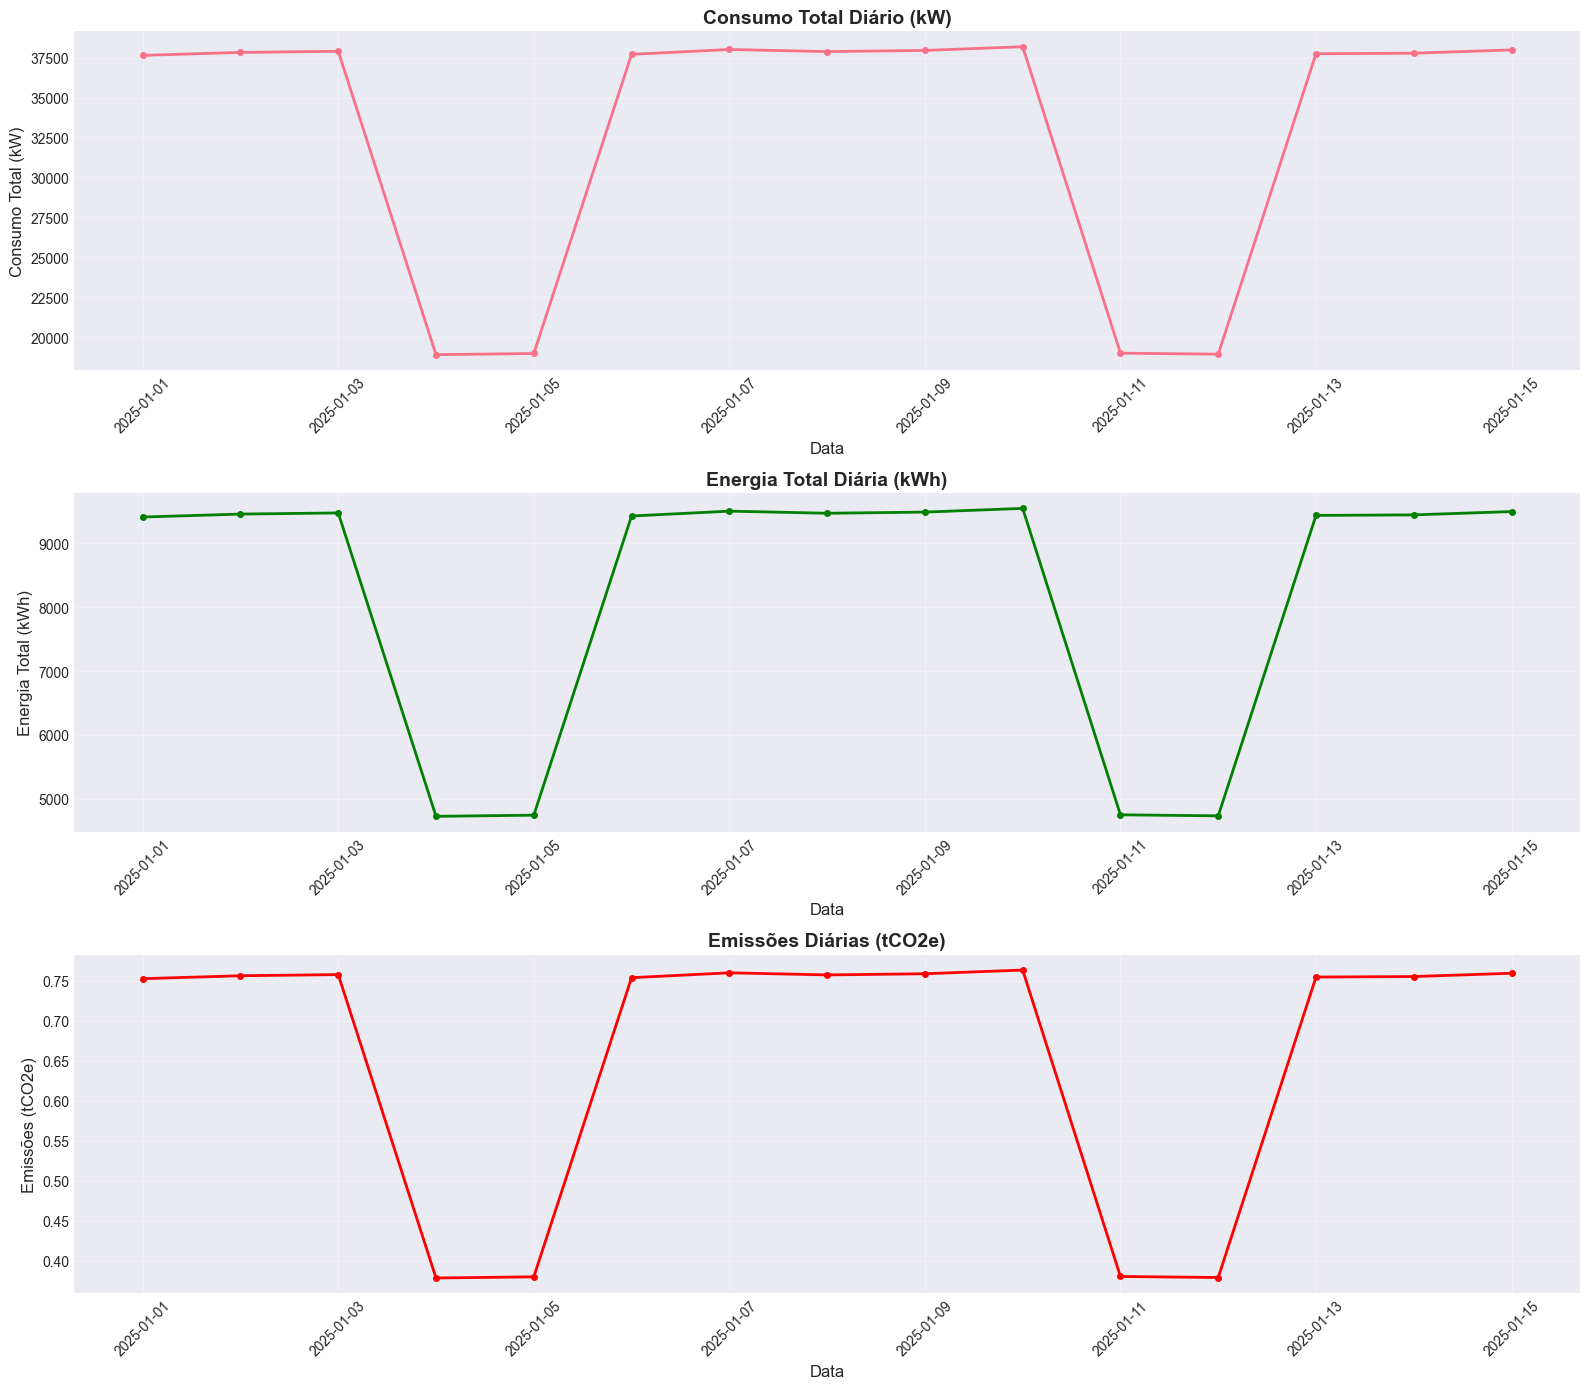

In [19]:
# Gráfico 3: Série temporal de consumo
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# 3.1 - Consumo total diário (kW)
ax1 = axes[0]
ax1.plot(consumo_diario['data'], consumo_diario['kw'], marker='o', linewidth=2, markersize=4)
ax1.set_title('Consumo Total Diário (kW)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Data', fontsize=12)
ax1.set_ylabel('Consumo Total (kW)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 3.2 - Consumo total diário (kWh)
ax2 = axes[1]
ax2.plot(consumo_diario['data'], consumo_diario['kwh_interval'], marker='o', linewidth=2, markersize=4, color='green')
ax2.set_title('Energia Total Diária (kWh)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Data', fontsize=12)
ax2.set_ylabel('Energia Total (kWh)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3.3 - Emissões diárias
ax3 = axes[2]
ax3.plot(consumo_diario['data'], consumo_diario['emissoes_tco2e'], marker='o', linewidth=2, markersize=4, color='red')
ax3.set_title('Emissões Diárias (tCO2e)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Data', fontsize=12)
ax3.set_ylabel('Emissões (tCO2e)', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


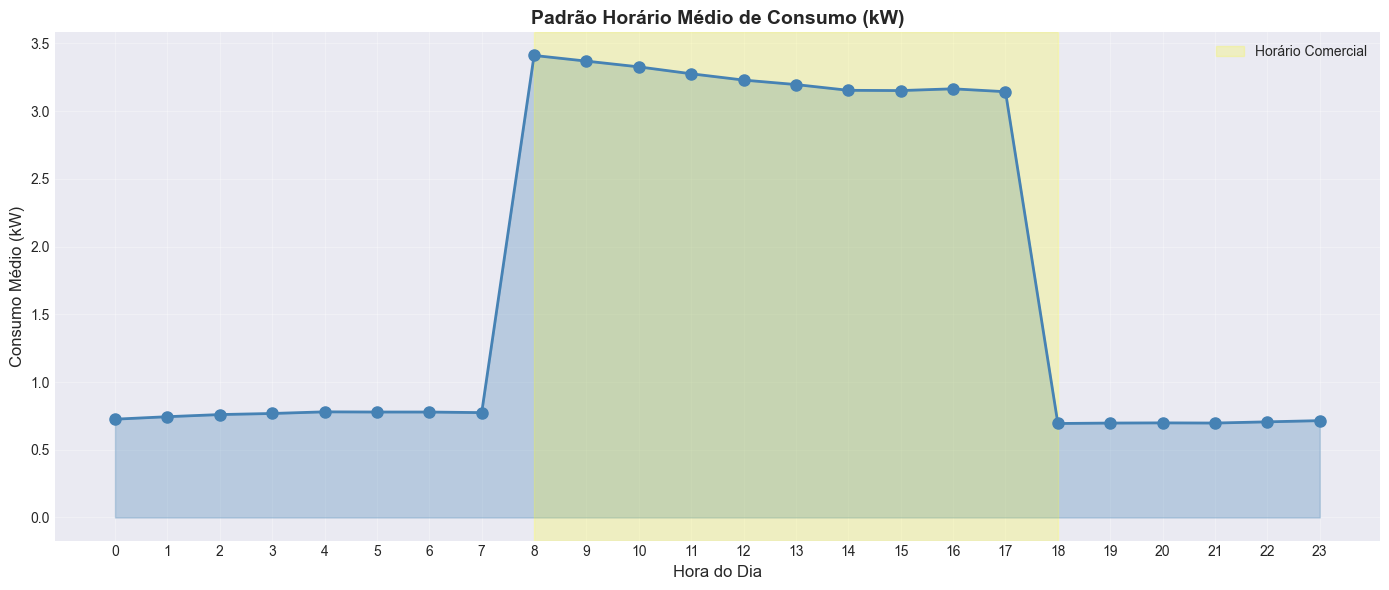

In [20]:
# Gráfico 4: Padrão horário de consumo
consumo_horario = df.groupby('hora')['kw'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(consumo_horario['hora'], consumo_horario['kw'], marker='o', linewidth=2, markersize=8, color='steelblue')
ax.fill_between(consumo_horario['hora'], consumo_horario['kw'], alpha=0.3, color='steelblue')
ax.set_title('Padrão Horário Médio de Consumo (kW)', fontsize=14, fontweight='bold')
ax.set_xlabel('Hora do Dia', fontsize=12)
ax.set_ylabel('Consumo Médio (kW)', fontsize=12)
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
ax.axvspan(8, 18, alpha=0.2, color='yellow', label='Horário Comercial')
ax.legend()
plt.tight_layout()
plt.show()


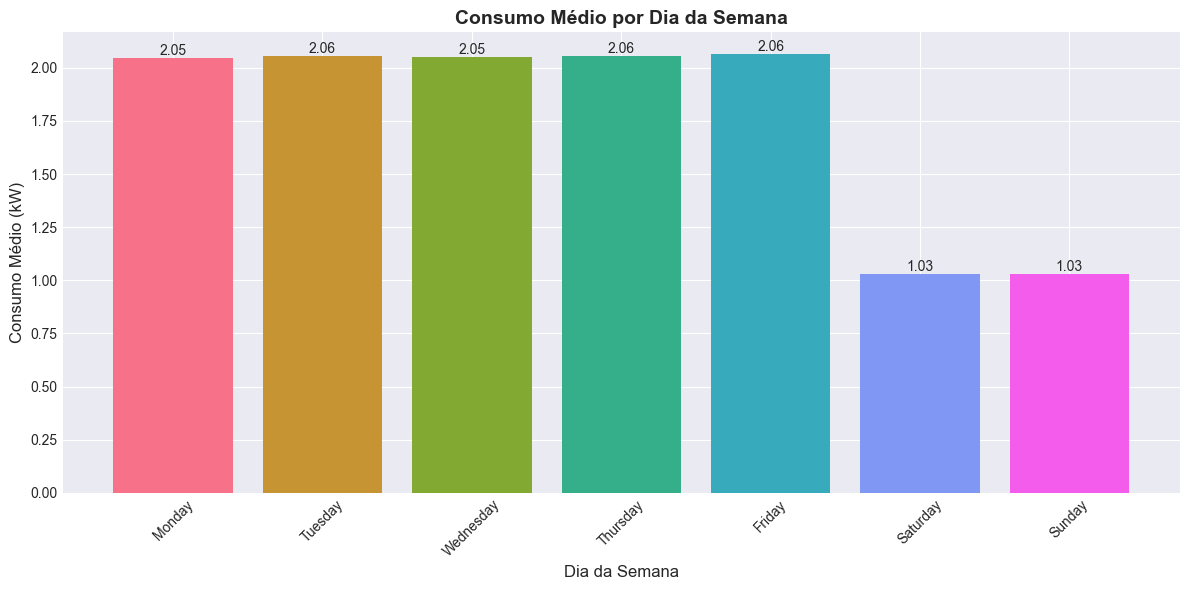

In [21]:
# Gráfico 5: Consumo por dia da semana
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
consumo_dia_semana = df.groupby('dia_semana')['kw'].mean().reindex(ordem_dias).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(consumo_dia_semana['dia_semana'], consumo_dia_semana['kw'], 
              color=sns.color_palette("husl", len(consumo_dia_semana)))
ax.set_title('Consumo Médio por Dia da Semana', fontsize=14, fontweight='bold')
ax.set_xlabel('Dia da Semana', fontsize=12)
ax.set_ylabel('Consumo Médio (kW)', fontsize=12)
ax.tick_params(axis='x', rotation=45)

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 6. Análise por Site e Andar


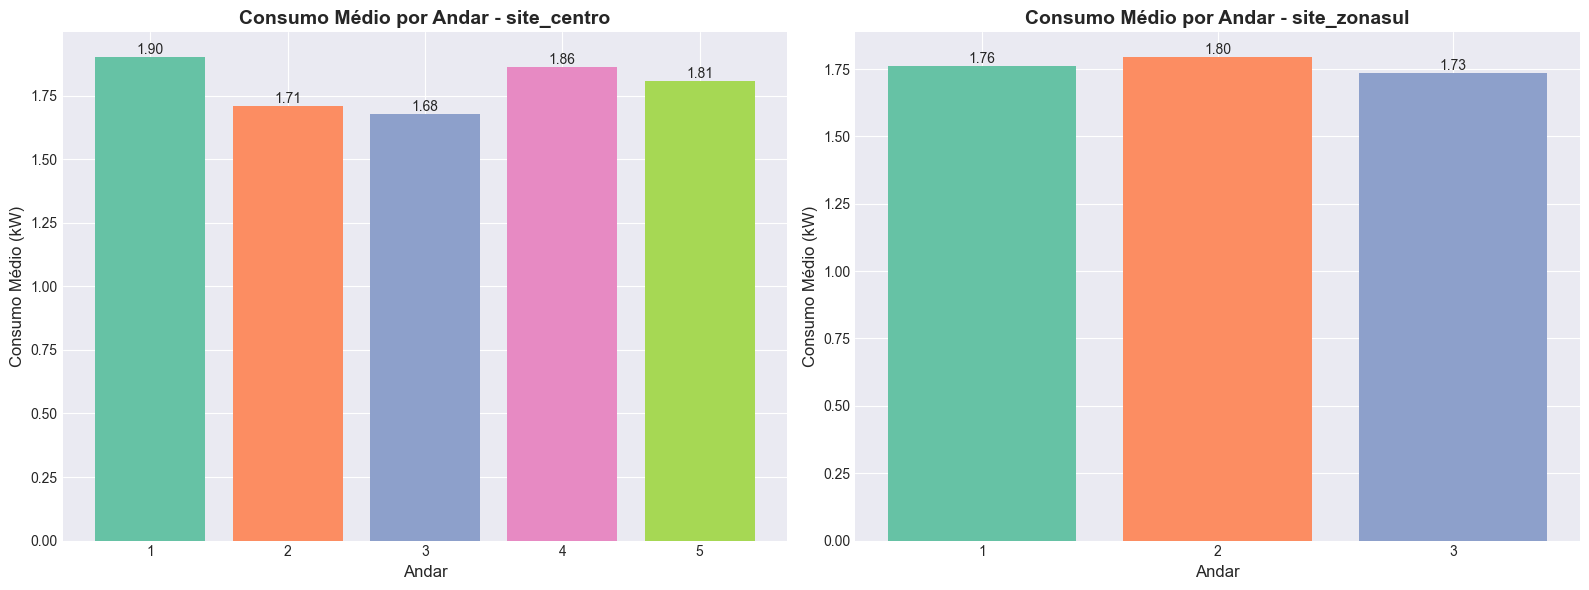

In [22]:
# Gráfico 6: Consumo por andar em cada site
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sites = df['site_id'].unique()
for idx, site in enumerate(sites):
    df_site = df[df['site_id'] == site]
    consumo_por_andar = df_site.groupby('andar')['kw'].mean().sort_index()
    
    ax = axes[idx]
    bars = ax.bar(consumo_por_andar.index.astype(str), consumo_por_andar.values, 
                  color=sns.color_palette("Set2", len(consumo_por_andar)))
    ax.set_title(f'Consumo Médio por Andar - {site}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Andar', fontsize=12)
    ax.set_ylabel('Consumo Médio (kW)', fontsize=12)
    
    # Adicionar valores nas barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 7. Análise de Relação com Temperatura


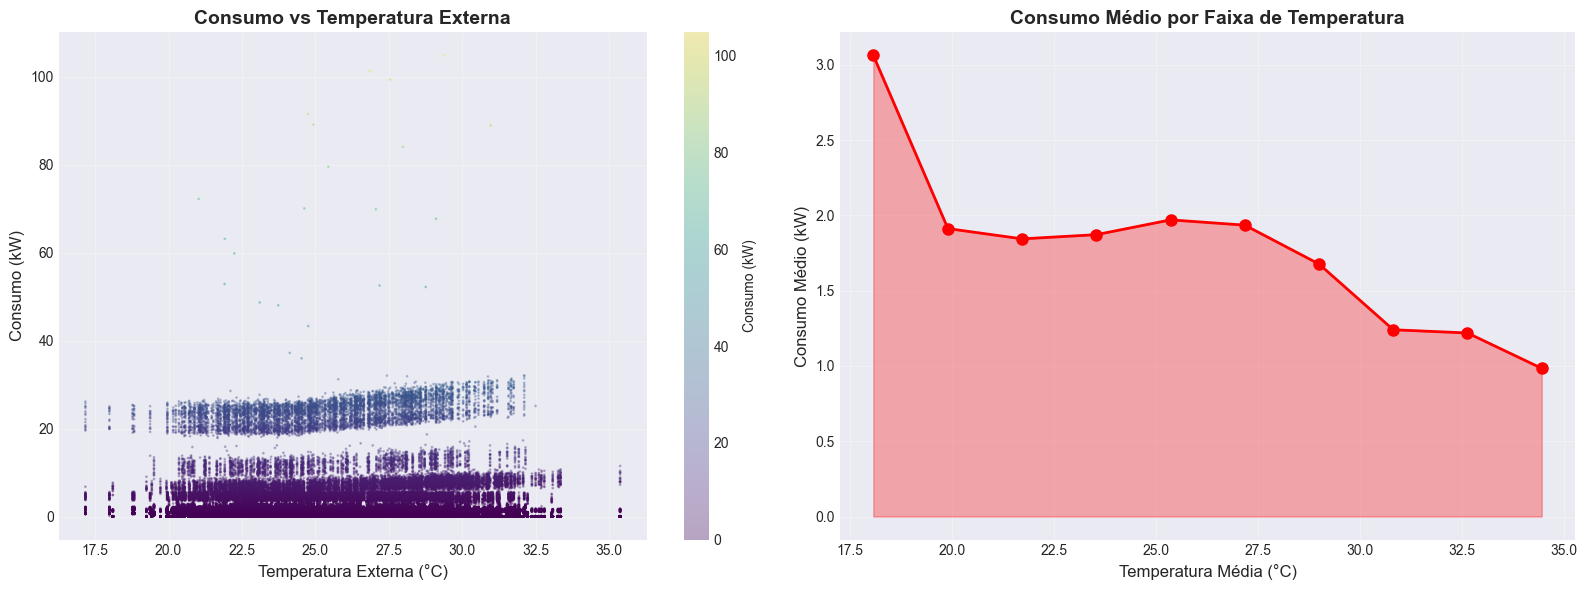

In [23]:
# Gráfico 7: Consumo vs Temperatura Externa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 7.1 - Scatter plot geral
ax1 = axes[0]
scatter = ax1.scatter(df['temp_ext'], df['kw'], alpha=0.3, s=1, c=df['kw'], cmap='viridis')
ax1.set_title('Consumo vs Temperatura Externa', fontsize=14, fontweight='bold')
ax1.set_xlabel('Temperatura Externa (°C)', fontsize=12)
ax1.set_ylabel('Consumo (kW)', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Consumo (kW)')

# 7.2 - Consumo médio por faixa de temperatura
df['temp_faixa'] = pd.cut(df['temp_ext'], bins=10)
consumo_por_temp = df.groupby('temp_faixa')['kw'].mean().reset_index()
consumo_por_temp['temp_medio'] = consumo_por_temp['temp_faixa'].apply(lambda x: x.mid)

ax2 = axes[1]
ax2.plot(consumo_por_temp['temp_medio'], consumo_por_temp['kw'], marker='o', linewidth=2, markersize=8, color='red')
ax2.fill_between(consumo_por_temp['temp_medio'], consumo_por_temp['kw'], alpha=0.3, color='red')
ax2.set_title('Consumo Médio por Faixa de Temperatura', fontsize=14, fontweight='bold')
ax2.set_xlabel('Temperatura Média (°C)', fontsize=12)
ax2.set_ylabel('Consumo Médio (kW)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


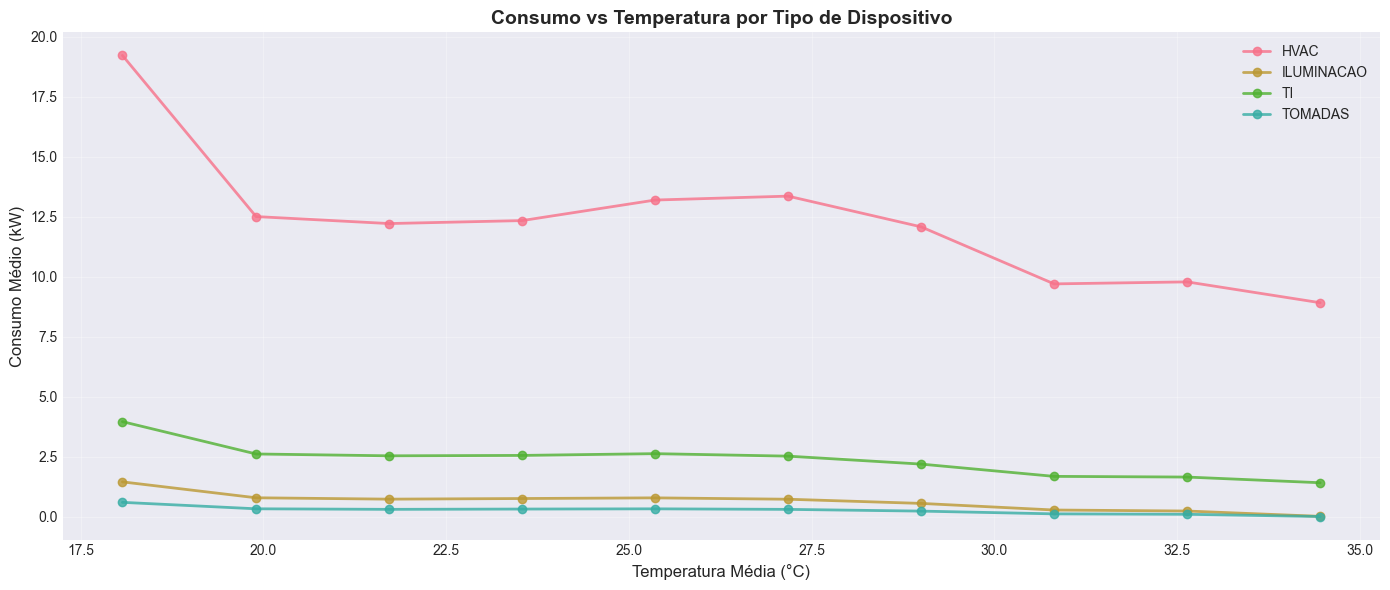

In [24]:
# Gráfico 8: Consumo vs Temperatura por tipo de dispositivo (foco em HVAC)
fig, ax = plt.subplots(figsize=(14, 6))

for device_type in df['device_type'].unique():
    df_type = df[df['device_type'] == device_type]
    consumo_por_temp = df_type.groupby(pd.cut(df_type['temp_ext'], bins=10))['kw'].mean()
    temp_medio = [interval.mid for interval in consumo_por_temp.index]
    ax.plot(temp_medio, consumo_por_temp.values, marker='o', linewidth=2, 
            markersize=6, label=device_type, alpha=0.8)

ax.set_title('Consumo vs Temperatura por Tipo de Dispositivo', fontsize=14, fontweight='bold')
ax.set_xlabel('Temperatura Média (°C)', fontsize=12)
ax.set_ylabel('Consumo Médio (kW)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Análise de Padrões: Finais de Semana vs Dias Úteis


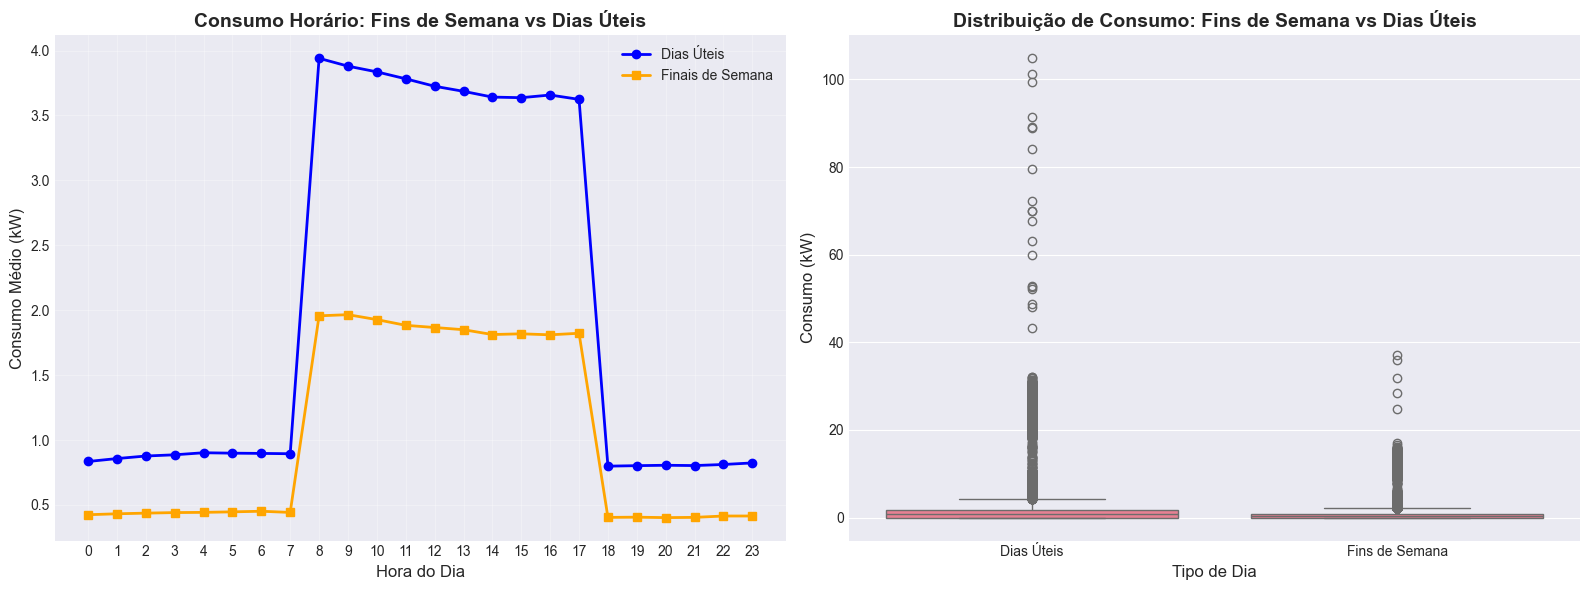

In [25]:
# Gráfico 9: Comparação de consumo: fim de semana vs dias úteis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 9.1 - Consumo por hora: fim de semana vs dias úteis
consumo_horario_fds = df[df['eh_fds'] == 1].groupby('hora')['kw'].mean()
consumo_horario_util = df[df['eh_fds'] == 0].groupby('hora')['kw'].mean()

ax1 = axes[0]
ax1.plot(consumo_horario_util.index, consumo_horario_util.values, marker='o', 
         linewidth=2, markersize=6, label='Dias Úteis', color='blue')
ax1.plot(consumo_horario_fds.index, consumo_horario_fds.values, marker='s', 
         linewidth=2, markersize=6, label='Finais de Semana', color='orange')
ax1.set_title('Consumo Horário: Fins de Semana vs Dias Úteis', fontsize=14, fontweight='bold')
ax1.set_xlabel('Hora do Dia', fontsize=12)
ax1.set_ylabel('Consumo Médio (kW)', fontsize=12)
ax1.set_xticks(range(0, 24))
ax1.legend()
ax1.grid(True, alpha=0.3)

# 9.2 - Boxplot comparativo
ax2 = axes[1]
df_comparacao = df.copy()
df_comparacao['tipo_dia'] = df_comparacao['eh_fds'].map({0: 'Dias Úteis', 1: 'Fins de Semana'})
sns.boxplot(data=df_comparacao, x='tipo_dia', y='kw', ax=ax2)
ax2.set_title('Distribuição de Consumo: Fins de Semana vs Dias Úteis', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tipo de Dia', fontsize=12)
ax2.set_ylabel('Consumo (kW)', fontsize=12)

plt.tight_layout()
plt.show()


## 9. Análise de Horário Comercial


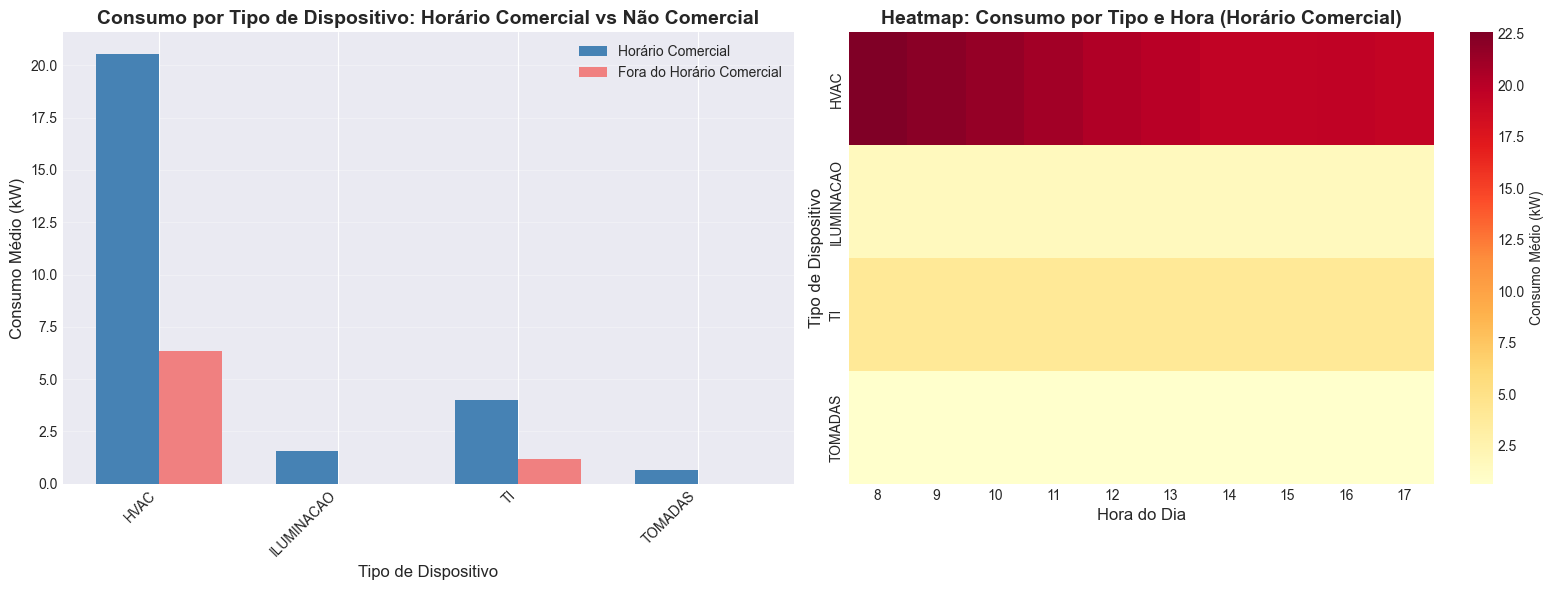

In [26]:
# Gráfico 10: Consumo em horário comercial vs não comercial
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 10.1 - Comparação por tipo de dispositivo
consumo_comercial = df[df['eh_horario_comercial'] == 1].groupby('device_type')['kw'].mean()
consumo_nao_comercial = df[df['eh_horario_comercial'] == 0].groupby('device_type')['kw'].mean()

x = np.arange(len(consumo_comercial.index))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, consumo_comercial.values, width, label='Horário Comercial', color='steelblue')
bars2 = ax1.bar(x + width/2, consumo_nao_comercial.values, width, label='Fora do Horário Comercial', color='lightcoral')
ax1.set_title('Consumo por Tipo de Dispositivo: Horário Comercial vs Não Comercial', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tipo de Dispositivo', fontsize=12)
ax1.set_ylabel('Consumo Médio (kW)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(consumo_comercial.index, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 10.2 - Heatmap de consumo por hora e tipo de dispositivo (horário comercial)
consumo_hora_tipo_comercial = df[df['eh_horario_comercial'] == 1].pivot_table(
    values='kw', index='device_type', columns='hora', aggfunc='mean'
)

ax2 = axes[1]
sns.heatmap(consumo_hora_tipo_comercial, annot=False, cmap='YlOrRd', ax=ax2, 
            cbar_kws={'label': 'Consumo Médio (kW)'})
ax2.set_title('Heatmap: Consumo por Tipo e Hora (Horário Comercial)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Hora do Dia', fontsize=12)
ax2.set_ylabel('Tipo de Dispositivo', fontsize=12)

plt.tight_layout()
plt.show()


## 10. Análise de Anomalias


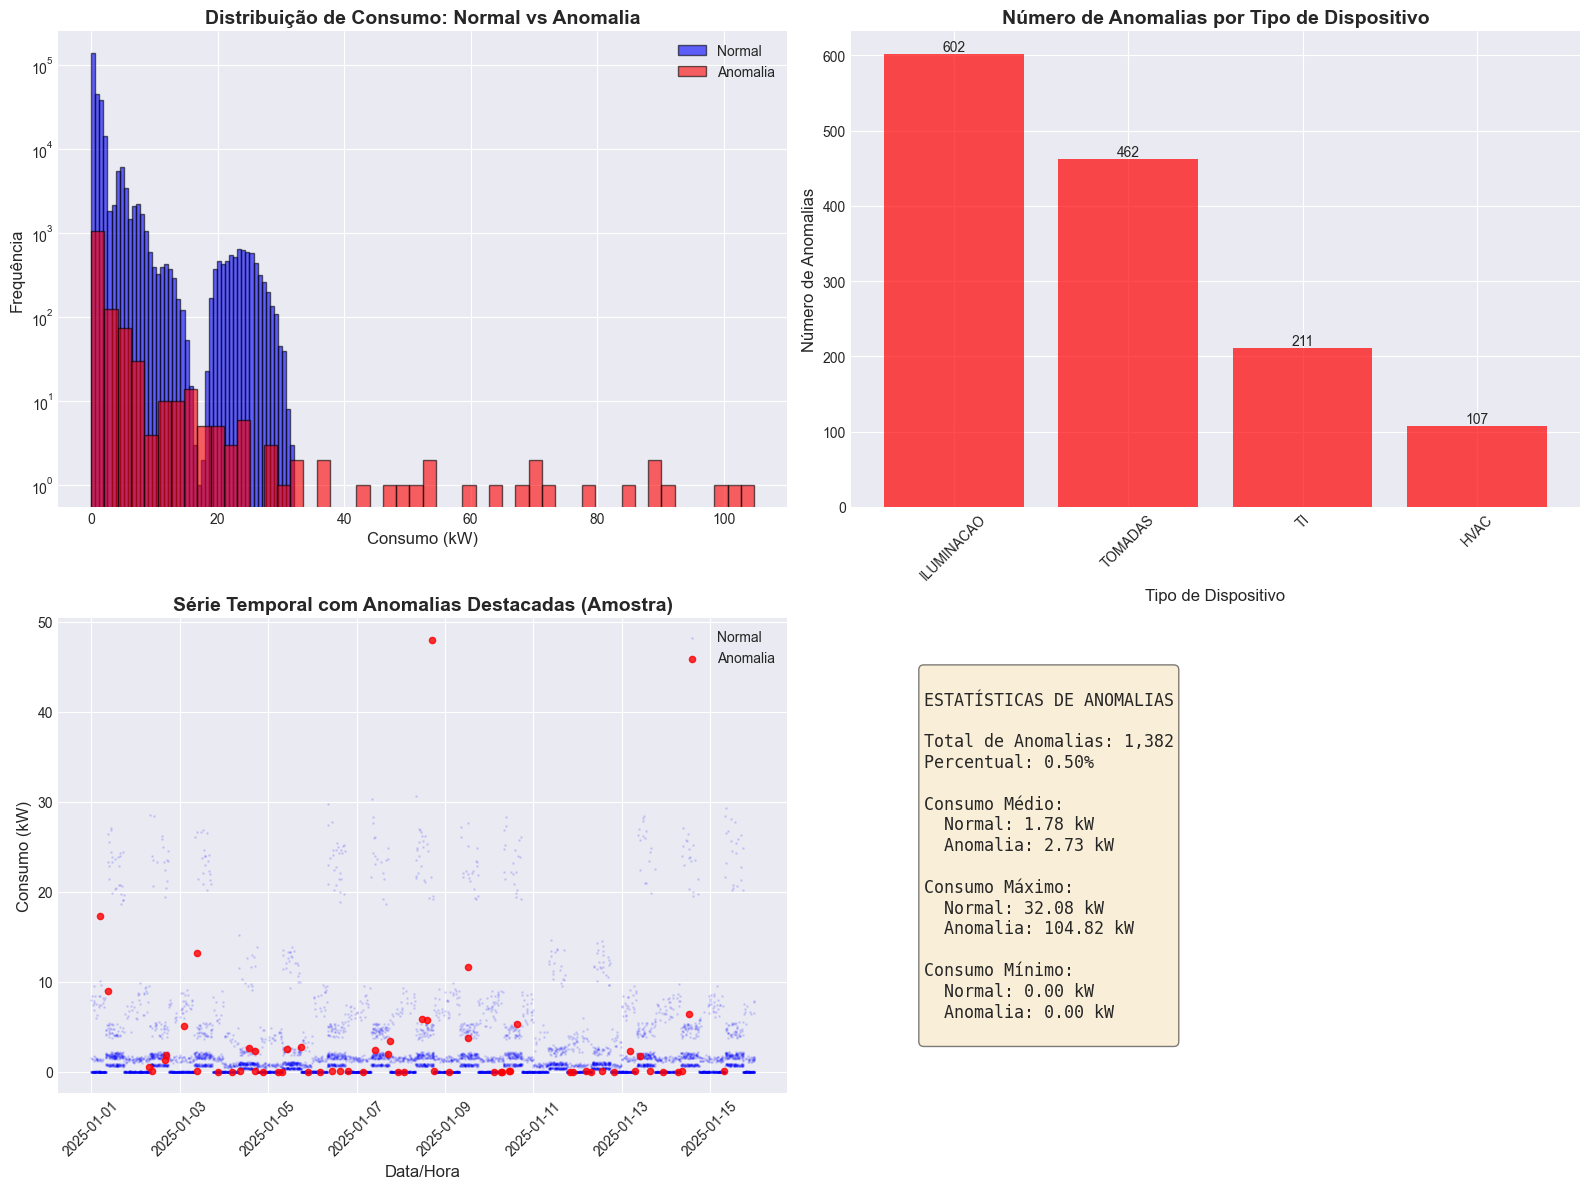

In [27]:
# Gráfico 11: Análise de anomalias
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 11.1 - Distribuição de consumo: normal vs anomalia
ax1 = axes[0, 0]
df_normal = df[df['is_anomaly'] == 0]['kw']
df_anomalia = df[df['is_anomaly'] == 1]['kw']
ax1.hist(df_normal, bins=50, alpha=0.6, label='Normal', color='blue', edgecolor='black')
ax1.hist(df_anomalia, bins=50, alpha=0.6, label='Anomalia', color='red', edgecolor='black')
ax1.set_title('Distribuição de Consumo: Normal vs Anomalia', fontsize=14, fontweight='bold')
ax1.set_xlabel('Consumo (kW)', fontsize=12)
ax1.set_ylabel('Frequência', fontsize=12)
ax1.legend()
ax1.set_yscale('log')

# 11.2 - Anomalias por tipo de dispositivo
ax2 = axes[0, 1]
anomalias_por_tipo = df[df['is_anomaly'] == 1]['device_type'].value_counts()
bars = ax2.bar(anomalias_por_tipo.index, anomalias_por_tipo.values, color='red', alpha=0.7)
ax2.set_title('Número de Anomalias por Tipo de Dispositivo', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tipo de Dispositivo', fontsize=12)
ax2.set_ylabel('Número de Anomalias', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

# 11.3 - Série temporal com anomalias destacadas
ax3 = axes[1, 0]
# Amostrar dados para visualização (muito dados para plotar tudo)
df_amostra = df.sample(min(10000, len(df)), random_state=42)
df_amostra = df_amostra.sort_values('ts')
ax3.scatter(df_amostra[df_amostra['is_anomaly'] == 0]['ts'], 
            df_amostra[df_amostra['is_anomaly'] == 0]['kw'], 
            alpha=0.1, s=1, color='blue', label='Normal')
ax3.scatter(df_amostra[df_amostra['is_anomaly'] == 1]['ts'], 
            df_amostra[df_amostra['is_anomaly'] == 1]['kw'], 
            alpha=0.8, s=20, color='red', label='Anomalia')
ax3.set_title('Série Temporal com Anomalias Destacadas (Amostra)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Data/Hora', fontsize=12)
ax3.set_ylabel('Consumo (kW)', fontsize=12)
ax3.legend()
ax3.tick_params(axis='x', rotation=45)

# 11.4 - Estatísticas comparativas
ax4 = axes[1, 1]
ax4.axis('off')
stats_text = f"""
ESTATÍSTICAS DE ANOMALIAS

Total de Anomalias: {df['is_anomaly'].sum():,}
Percentual: {df['is_anomaly'].mean()*100:.2f}%

Consumo Médio:
  Normal: {df[df['is_anomaly']==0]['kw'].mean():.2f} kW
  Anomalia: {df[df['is_anomaly']==1]['kw'].mean():.2f} kW

Consumo Máximo:
  Normal: {df[df['is_anomaly']==0]['kw'].max():.2f} kW
  Anomalia: {df[df['is_anomaly']==1]['kw'].max():.2f} kW

Consumo Mínimo:
  Normal: {df[df['is_anomaly']==0]['kw'].min():.2f} kW
  Anomalia: {df[df['is_anomaly']==1]['kw'].min():.2f} kW
"""
ax4.text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center',
         family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


## 11. Análise de Correlações


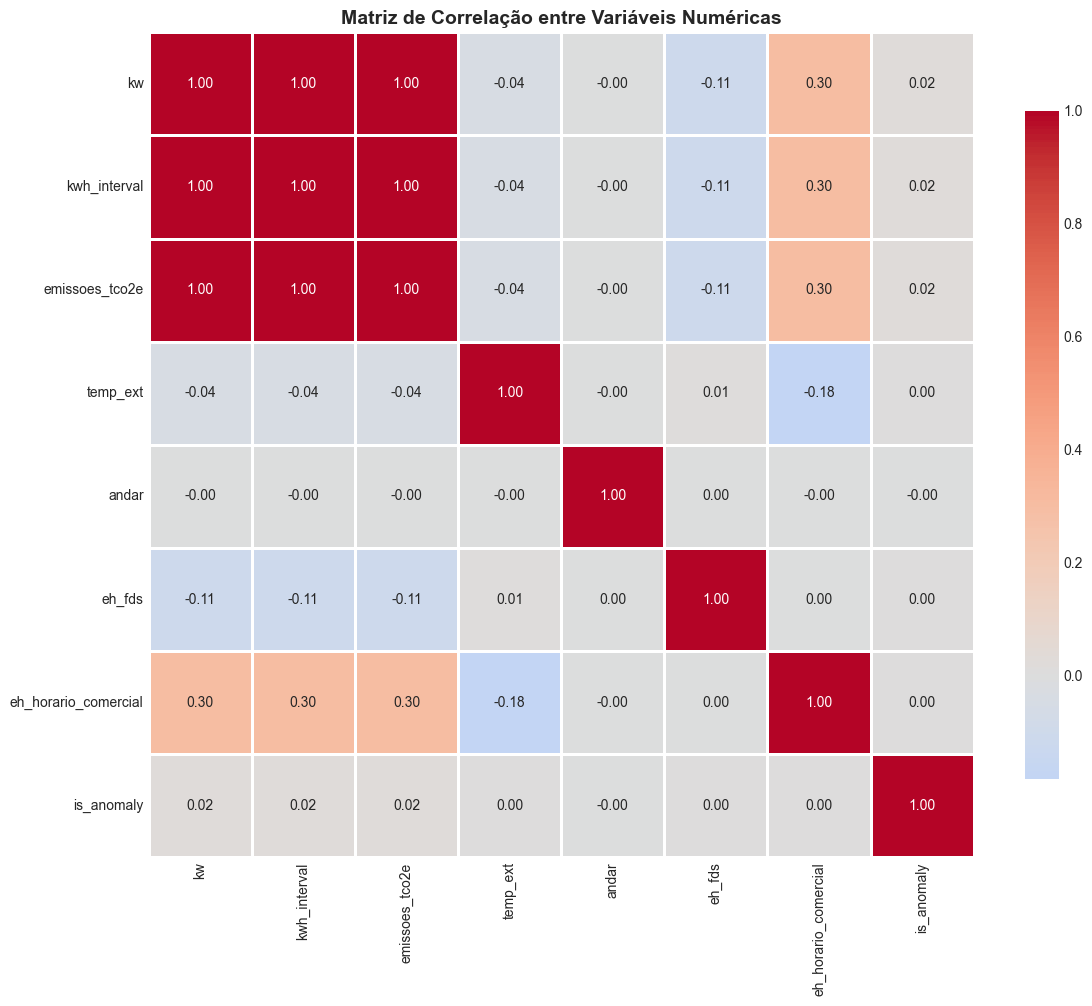

In [28]:
# Gráfico 12: Matriz de correlação
# Selecionar apenas variáveis numéricas
variaveis_numericas = ['kw', 'kwh_interval', 'emissoes_tco2e', 'temp_ext', 
                       'andar', 'eh_fds', 'eh_horario_comercial', 'is_anomaly']
correlacao = df[variaveis_numericas].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Matriz de Correlação entre Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Resumo Estatístico por Categoria


In [29]:
# Resumo estatístico detalhado
print("=" * 80)
print("RESUMO ESTATÍSTICO POR TIPO DE DISPOSITIVO")
print("=" * 80)

resumo_por_tipo = df.groupby('device_type').agg({
    'kw': ['count', 'mean', 'std', 'min', 'max', 'sum'],
    'kwh_interval': 'sum',
    'emissoes_tco2e': 'sum'
}).round(2)

print("\n", resumo_por_tipo)

print("\n" + "=" * 80)
print("RESUMO ESTATÍSTICO POR SITE")
print("=" * 80)

resumo_por_site = df.groupby('site_id').agg({
    'kw': ['count', 'mean', 'std', 'min', 'max', 'sum'],
    'kwh_interval': 'sum',
    'emissoes_tco2e': 'sum'
}).round(2)

print("\n", resumo_por_site)


RESUMO ESTATÍSTICO POR TIPO DE DISPOSITIVO

                  kw                                       kwh_interval  \
              count   mean   std   min     max        sum          sum   
device_type                                                              
HVAC          23040  12.26  8.25  0.05  104.82  282581.10     70645.28   
ILUMINACAO   115200   0.65  0.82  0.00    8.19   75132.22     18783.06   
TI            46080   2.38  1.62  0.00   22.95  109664.76     27416.19   
TOMADAS       92160   0.27  0.34  0.00    3.25   25026.89      6256.72   

            emissoes_tco2e  
                       sum  
device_type                 
HVAC                  5.65  
ILUMINACAO            1.50  
TI                    2.19  
TOMADAS               0.50  

RESUMO ESTATÍSTICO POR SITE

                   kw                                     kwh_interval  \
               count  mean   std  min     max        sum          sum   
site_id                                                 

## 13. Insights e Conclusões

### Principais Descobertas:

1. **Padrões Temporais**: 
   - Consumo varia significativamente ao longo do dia
   - Pico de consumo durante horário comercial (8h-18h)
   - Consumo reduzido em finais de semana

2. **Tipos de Dispositivos**:
   - HVAC apresenta maior consumo médio
   - Dispositivos de TI e Iluminação têm padrões distintos

3. **Temperatura**:
   - Correlação positiva entre temperatura e consumo (especialmente HVAC)
   - Maior consumo em dias mais quentes

4. **Anomalias**:
   - Anomalias detectadas representam padrões de consumo atípicos
   - Necessário monitoramento contínuo

5. **Emissões**:
   - Emissões de CO2 seguem padrão similar ao consumo de energia
   - Oportunidades de redução identificadas
